# Gradient Descent for Linear Regression

This notebook implements gradient descent from scratch and visualizes how the squared-error objective decreases.


In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
X = np.array([[1.0], [2.0], [3.0], [4.0], [5.0]])
y = np.array([2.2, 3.9, 6.1, 7.8, 10.2])
X_aug = np.c_[np.ones(len(X)), X]
print(f'Training data: {len(X)} observations')


Training data: 5 observations


## Loss and gradient

For $n$ training examples, the squared-error objective is

$$
J(\theta)=\frac{1}{2n}\sum_{i=1}^{n}(\theta^T x_i-y_i)^2.
$$

The corresponding gradient is

$$
\nabla J(\theta)=\frac{1}{n}X^T(X\theta-y).
$$

The factor $1/n$ is included in both functions so that the implementation matches the lecture objective exactly.


In [3]:
def loss(X, y, theta):
    errors = X @ theta - y
    return np.sum(errors ** 2) / (2 * len(y))

def gradient(X, y, theta):
    errors = X @ theta - y
    return X.T @ errors / len(y)


## Gradient descent

Start from an unoptimized parameter vector and repeatedly move in the opposite direction of the gradient. The loss is recorded at every iteration so that the convergence plot contains the actual objective values produced during optimization.


In [4]:
theta = np.zeros(X_aug.shape[1])
learning_rate = 0.01
iterations = 5000
history = []

for _ in range(iterations):
    history.append(loss(X_aug, y, theta))
    theta -= learning_rate * gradient(X_aug, y, theta)

print('Initial objective:', history[0])
print('Final objective:', history[-1])
print('Learned theta:', theta)


Initial objective: 22.214
Final objective: 0.013100000818684255
Learned theta: [0.07009469 1.98997377]


## 1. Objective decreases


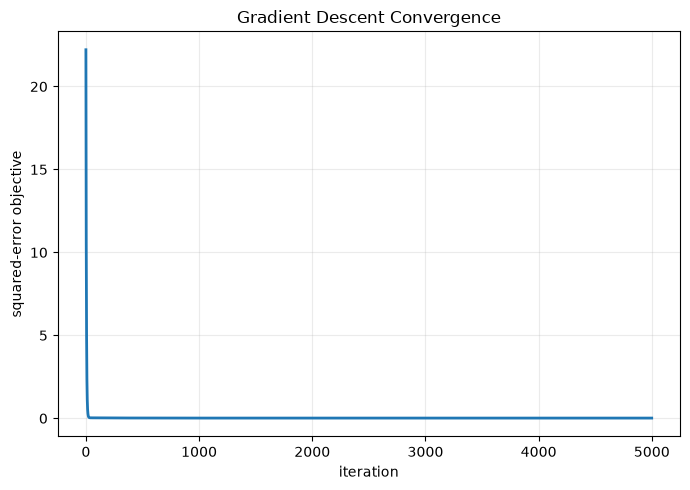

In [5]:
plt.figure(figsize=(7, 5))
plt.plot(history, linewidth=2)
plt.xlabel('iteration')
plt.ylabel('squared-error objective')
plt.title('Gradient Descent Convergence')
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


## 2. Learned regression line

The five training observations are shown as points, so we can see what the learned model is trying to fit.


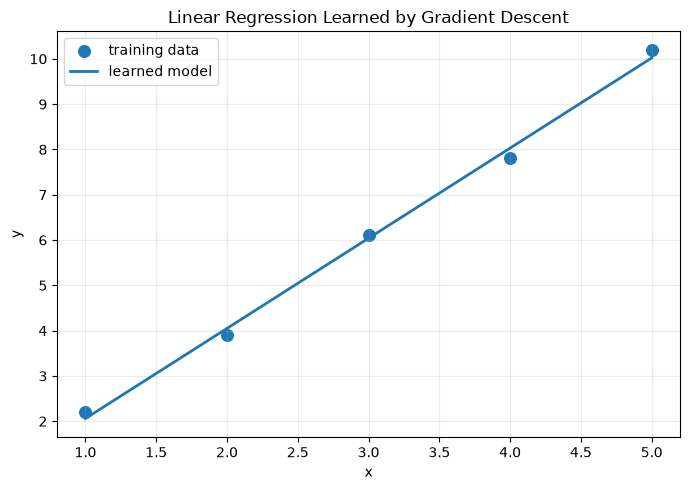

In [6]:
xx = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
yy = np.c_[np.ones(len(xx)), xx] @ theta
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], y, s=70, label='training data')
plt.plot(xx[:, 0], yy, linewidth=2, label='learned model')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression Learned by Gradient Descent')
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()
